# 05 — V5: Secondary Eclipse View

**Goal:** Eliminate V4's eclipsing-binary false positives by giving the CNN a second phase-folded view centered on the secondary eclipse location (phase = period/2 after primary).

V4 recap: 100% recall, 75% accuracy on 16 real Kepler TCEs. 4 false positives, all eclipsing binaries.

**Success criterion:** precision > 80% with recall staying at 100%.

Architecture change vs. V4: `forward(phase, primary_flux, secondary_flux)` — three channels into the CNN, Taylor gate stays on primary only.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from src.models.taylor_cnn import TaylorCNN
from src.data.synthetic import make_synthetic_batch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load dataset (V5 format: includes `fluxes_secondary`)

In [2]:
dataset = torch.load('../data/kepler_tce.pt', weights_only=False)

assert 'fluxes_secondary' in dataset, (
    'Dataset is in V4 format. Re-run: '
    'python -m src.data.build_dataset --n-per-class 50 --output data/kepler_tce.pt'
)

phases = dataset['phases']                       # (N, 200)
fluxes_primary = dataset['fluxes']               # (N, 200)
fluxes_secondary = dataset['fluxes_secondary']   # (N, 200)  ← V5 addition
labels = dataset['labels']                       # (N,)
names = dataset['names']
depths = dataset['depths_ppm']

n_conf = int(labels.sum())
n_fp = int((1 - labels).sum())
print(f'Dataset: {len(labels)} TCEs ({n_conf} confirmed, {n_fp} FP)')
print(f'Primary min dips:   {fluxes_primary.min(dim=1).values.median():.4f} (median across TCEs)')
print(f'Secondary min dips: {fluxes_secondary.min(dim=1).values.median():.4f} (median across TCEs)')

Dataset: 100 TCEs (50 confirmed, 50 FP)
Primary min dips:   -0.0025 (median across TCEs)
Secondary min dips: -0.0025 (median across TCEs)


## 2. Visualize primary + secondary for a confirmed planet and a known FP

For a planet, the secondary should look like flat noise. For an EB, the secondary should show a clear dip at phase=0.

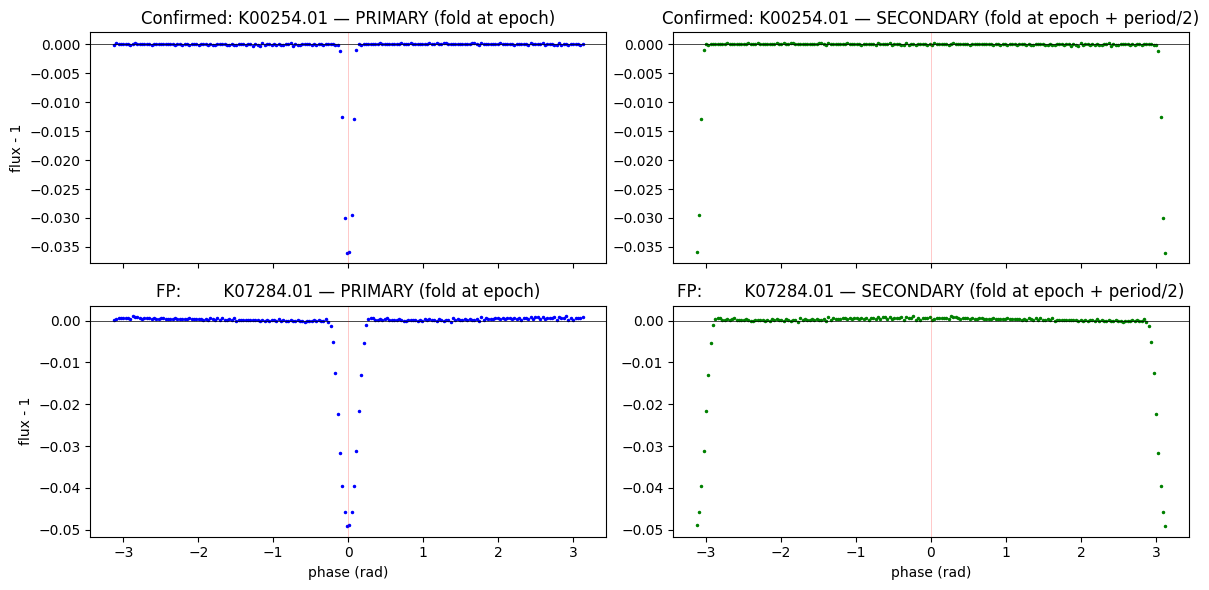

In [3]:
# Pick the deepest-dip confirmed planet and the deepest-dip FP in the whole set
conf_idx = (labels == 1).nonzero(as_tuple=True)[0]
fp_idx = (labels == 0).nonzero(as_tuple=True)[0]

ex_planet = conf_idx[fluxes_primary[conf_idx].min(dim=1).values.argmin()].item()
ex_fp     = fp_idx[fluxes_primary[fp_idx].min(dim=1).values.argmin()].item()

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for row, (idx, title_prefix) in enumerate([
    (ex_planet, f'Confirmed: {names[ex_planet]}'),
    (ex_fp,     f'FP:        {names[ex_fp]}'),
]):
    axes[row, 0].plot(phases[idx], fluxes_primary[idx], 'b.', ms=3)
    axes[row, 0].axhline(0, color='k', lw=0.5)
    axes[row, 0].axvline(0, color='r', lw=0.5, alpha=0.3)
    axes[row, 0].set_title(f'{title_prefix} — PRIMARY (fold at epoch)')
    axes[row, 0].set_ylabel('flux - 1')

    axes[row, 1].plot(phases[idx], fluxes_secondary[idx], 'g.', ms=3)
    axes[row, 1].axhline(0, color='k', lw=0.5)
    axes[row, 1].axvline(0, color='r', lw=0.5, alpha=0.3)
    axes[row, 1].set_title(f'{title_prefix} — SECONDARY (fold at epoch + period/2)')

for ax in axes[-1]:
    ax.set_xlabel('phase (rad)')
plt.tight_layout()
plt.show()

## 3. Train / Val / Test split — seed 42 preserves the V4 test set exactly

Using the same stratified split as notebook 04 so the 16-TCE test set is identical. This keeps the V5 numbers directly comparable to V4.

In [4]:
torch.manual_seed(42)

conf_perm = conf_idx[torch.randperm(len(conf_idx))]
fp_perm = fp_idx[torch.randperm(len(fp_idx))]

def split_indices(indices, train_frac=0.7, val_frac=0.15):
    n = len(indices)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    return indices[:n_train], indices[n_train:n_train+n_val], indices[n_train+n_val:]

conf_train, conf_val, conf_test = split_indices(conf_perm)
fp_train, fp_val, fp_test = split_indices(fp_perm)

train_idx = torch.cat([conf_train, fp_train])
val_idx   = torch.cat([conf_val,   fp_val])
test_idx  = torch.cat([conf_test,  fp_test])

def make_split(idx):
    return (
        phases[idx].to(device),
        fluxes_primary[idx].to(device),
        fluxes_secondary[idx].to(device),
        labels[idx].to(device),
    )

train_ph, train_p, train_s, train_l = make_split(train_idx)
val_ph,   val_p,   val_s,   val_l   = make_split(val_idx)
test_ph,  test_p,  test_s,  test_l  = make_split(test_idx)

print(f'Train: {len(train_l)} ({int(train_l.sum())} conf, {int((1-train_l).sum())} FP)')
print(f'Val:   {len(val_l)} ({int(val_l.sum())} conf, {int((1-val_l).sum())} FP)')
print(f'Test:  {len(test_l)} ({int(test_l.sum())} conf, {int((1-test_l).sum())} FP)  ← same 16 as V4')

Train: 70 (35 conf, 35 FP)
Val:   14 (7 conf, 7 FP)
Test:  16 (8 conf, 8 FP)  ← same 16 as V4


## 4. Build model

V4 used synthetic pretraining. For V5 that actually hurts: the synthetic EB class pushes the Taylor gate amplitude `A` up to ~0.08 (tuned for synthetic 1–2% depths), and BatchNorm running stats computed on synthetic data transfer poorly to real Kepler data — fine-tune loss starts at 1.9 (worse than chance) and never recovers to the from-scratch optimum.

Set `USE_SYNTHETIC_PRETRAIN = True` below to re-run the pretraining path for comparison. The 3-class generator (`make_synthetic_batch` with `n_eclipsing_binaries > 0`) stays available in `src/data/synthetic.py` for future experiments where the synthetic/real gap can be closed (e.g., matching depth distributions or resetting BN stats between stages).

In [5]:
USE_SYNTHETIC_PRETRAIN = False

torch.manual_seed(7)
model = TaylorCNN(init_amplitude=0.01).to(device)
criterion = nn.BCELoss()
print(f'Model params: {sum(p.numel() for p in model.parameters())}')

if USE_SYNTHETIC_PRETRAIN:
    syn_ph, syn_p, syn_s, syn_l = make_synthetic_batch(
        n_planets=200,
        n_eclipsing_binaries=100,
        n_non_transits=100,
        depth_range=(0.005, 0.02),
        eb_secondary_range=(0.003, 0.015),
        noise_level=0.003,
        seed=123,
    )
    syn_ph, syn_p, syn_s, syn_l = (t.to(device) for t in (syn_ph, syn_p, syn_s, syn_l))
    pre_opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    bs, n_pre = 32, 40
    n_syn = len(syn_l)
    print(f'\nPretraining on synthetic ({n_syn} examples, {n_pre} epochs)')
    for epoch in range(n_pre):
        model.train()
        perm = torch.randperm(n_syn, device=device)
        running_loss = 0.0
        correct = 0
        for start in range(0, n_syn, bs):
            idx = perm[start:start + bs]
            pred = model(syn_ph[idx], syn_p[idx], syn_s[idx]).squeeze(1)
            loss = criterion(pred, syn_l[idx])
            pre_opt.zero_grad()
            loss.backward()
            pre_opt.step()
            running_loss += loss.item() * len(idx)
            correct += ((pred > 0.5).float() == syn_l[idx]).sum().item()
        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(f'  epoch {epoch+1:>3}  loss={running_loss/n_syn:.4f}  acc={correct/n_syn:.1%}  A={model.taylor_gate.A.item():.5f}')
    print(f'\nPretrained A = {model.taylor_gate.A.item():.5f}')
else:
    print('Skipping synthetic pretraining — training from scratch on real Kepler TCEs.')

Model params: 856
Skipping synthetic pretraining — training from scratch on real Kepler TCEs.


## 5. Train on the 70 real Kepler TCEs

BCE loss, Adam with per-parameter-group learning rates (Taylor gate slower than CNN so it anchors near the median transit depth), early stopping on val loss. If pretraining was enabled above, this fine-tunes from that state; otherwise it trains from scratch.

In [6]:
optimizer = torch.optim.Adam([
    {'params': model.taylor_gate.parameters(), 'lr': 1e-4},
    {'params': model.cnn.parameters(),         'lr': 1e-3},
    {'params': model.classifier.parameters(),  'lr': 1e-3},
])

batch_size = 16
n_epochs = 200      # from-scratch path benefits from more epochs
n_train = len(train_l)
patience = 25

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'A': []}
best_val_loss = float('inf')
best_state = None
wait = 0

print(f'Training on {n_train} real TCEs')
print(f'{"Epoch":>5} {"Train Loss":>11} {"Val Loss":>10} {"Train Acc":>10} {"Val Acc":>9} {"A":>8}')
print('-' * 58)

for epoch in range(n_epochs):
    model.train()
    perm = torch.randperm(n_train, device=device)
    epoch_loss = 0.0
    epoch_correct = 0

    for start in range(0, n_train, batch_size):
        idx = perm[start:start + batch_size]
        pred = model(train_ph[idx], train_p[idx], train_s[idx]).squeeze(1)
        loss = criterion(pred, train_l[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)
        epoch_correct += ((pred > 0.5).float() == train_l[idx]).sum().item()

    train_loss = epoch_loss / n_train
    train_acc = epoch_correct / n_train

    model.eval()
    with torch.no_grad():
        vp = model(val_ph, val_p, val_s).squeeze(1)
        val_loss = criterion(vp, val_l).item()
        val_acc = ((vp > 0.5).float() == val_l).float().mean().item()

    A = model.taylor_gate.A.item()
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['A'].append(A)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch == 0 or (epoch + 1) % 20 == 0 or wait == patience:
        marker = ' *' if wait == 0 else ''
        print(f'{epoch+1:>5} {train_loss:>11.4f} {val_loss:>10.4f} {train_acc:>9.1%} {val_acc:>9.1%} {A:>8.5f}{marker}')

    if wait >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

model.load_state_dict(best_state)
print(f'\nRestored best model (val_loss={best_val_loss:.4f}, A={model.taylor_gate.A.item():.5f})')

Training on 70 real TCEs
Epoch  Train Loss   Val Loss  Train Acc   Val Acc        A
----------------------------------------------------------
    1      0.7018     0.7017     50.0%     50.0%  0.00969 *
   20      0.6617     0.6413     62.9%     85.7%  0.01365 *
   40      0.6341     0.5837     64.3%     78.6%  0.01530
   60      0.6273     0.5621     67.1%     78.6%  0.01542 *
   80      0.6188     0.5706     70.0%     78.6%  0.01510
  100      0.6199     0.5572     68.6%     78.6%  0.01490
  120      0.6126     0.5472     68.6%     78.6%  0.01504
  140      0.6111     0.5498     68.6%     71.4%  0.01507
  160      0.6297     0.5455     58.6%     78.6%  0.01528
  180      0.6054     0.5402     67.1%     78.6%  0.01541
  200      0.6088     0.5232     67.1%     78.6%  0.01516 *

Restored best model (val_loss=0.5232, A=0.01516)


## 6. Training curves

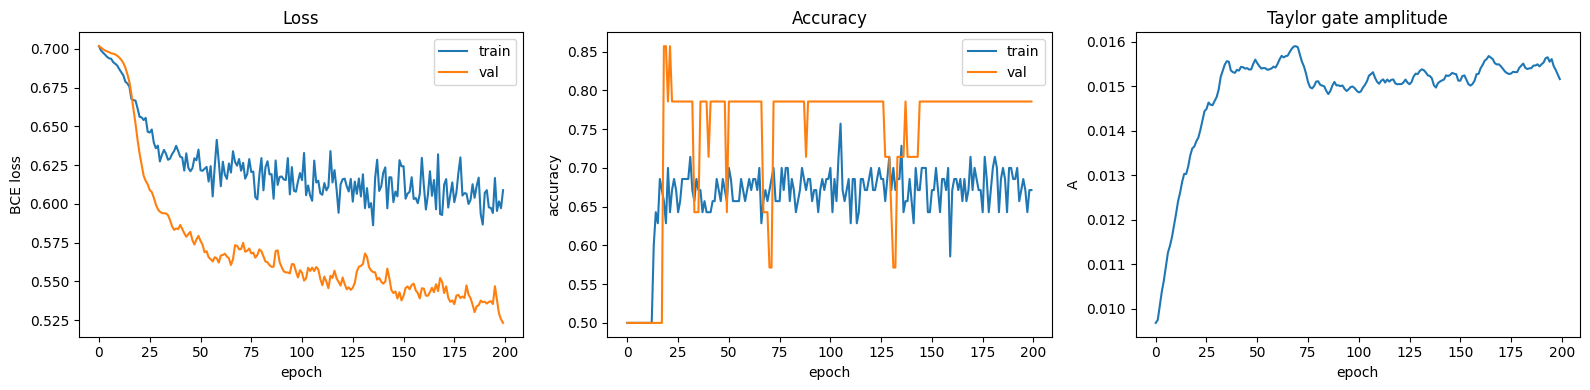

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.plot(history['train_loss'], label='train')
ax1.plot(history['val_loss'],   label='val')
ax1.set_xlabel('epoch'); ax1.set_ylabel('BCE loss'); ax1.legend(); ax1.set_title('Loss')

ax2.plot(history['train_acc'], label='train')
ax2.plot(history['val_acc'],   label='val')
ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy'); ax2.legend(); ax2.set_title('Accuracy')

ax3.plot(history['A'])
ax3.set_xlabel('epoch'); ax3.set_ylabel('A'); ax3.set_title('Taylor gate amplitude')

plt.tight_layout(); plt.show()

## 7. Test-set evaluation (same 16 TCEs as V4)

In [8]:
model.eval()
with torch.no_grad():
    test_probs = model(test_ph, test_p, test_s).squeeze(1).cpu()
test_preds = (test_probs > 0.5).float()
test_labels_cpu = test_l.cpu()

tp = int(((test_preds == 1) & (test_labels_cpu == 1)).sum())
tn = int(((test_preds == 0) & (test_labels_cpu == 0)).sum())
fp_ct = int(((test_preds == 1) & (test_labels_cpu == 0)).sum())
fn = int(((test_preds == 0) & (test_labels_cpu == 1)).sum())

accuracy  = (tp + tn) / (tp + tn + fp_ct + fn)
precision = tp / (tp + fp_ct) if (tp + fp_ct) > 0 else 0.0
recall    = tp / (tp + fn)    if (tp + fn)    > 0 else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print('=== V5 Test Set Results (16 TCEs, same set as V4) ===')
print(f'Accuracy:  {accuracy:.1%}  (V4: 75.0%)')
print(f'Precision: {precision:.1%}  (V4: 66.7%)')
print(f'Recall:    {recall:.1%}     (V4: 100.0%)')
print(f'F1:        {f1:.3f}        (V4: 0.800)')
print()
print('Confusion Matrix:')
print('                    Pred Planet  Pred Not')
print(f'  True Planet            {tp:>2}         {fn:>2}')
print(f'  True Not-Planet        {fp_ct:>2}         {tn:>2}')

success_precision = precision > 0.80
success_recall = recall >= 1.00
print()
print(f'Success criterion: precision > 80% AND recall = 100%')
print(f'  precision > 80%:  {"PASS" if success_precision else "FAIL"} ({precision:.1%})')
print(f'  recall  = 100%:  {"PASS" if success_recall   else "FAIL"} ({recall:.1%})')

=== V5 Test Set Results (16 TCEs, same set as V4) ===
Accuracy:  81.2%  (V4: 75.0%)
Precision: 72.7%  (V4: 66.7%)
Recall:    100.0%     (V4: 100.0%)
F1:        0.842        (V4: 0.800)

Confusion Matrix:
                    Pred Planet  Pred Not
  True Planet             8          0
  True Not-Planet         3          5

Success criterion: precision > 80% AND recall = 100%
  precision > 80%:  FAIL (72.7%)
  recall  = 100%:  PASS (100.0%)


## 8. Inspect false positives (if any remain)

For each FP that survived, look at the secondary channel — did the model miss a secondary dip, or was one absent?

3 FPs remain. Inspecting...


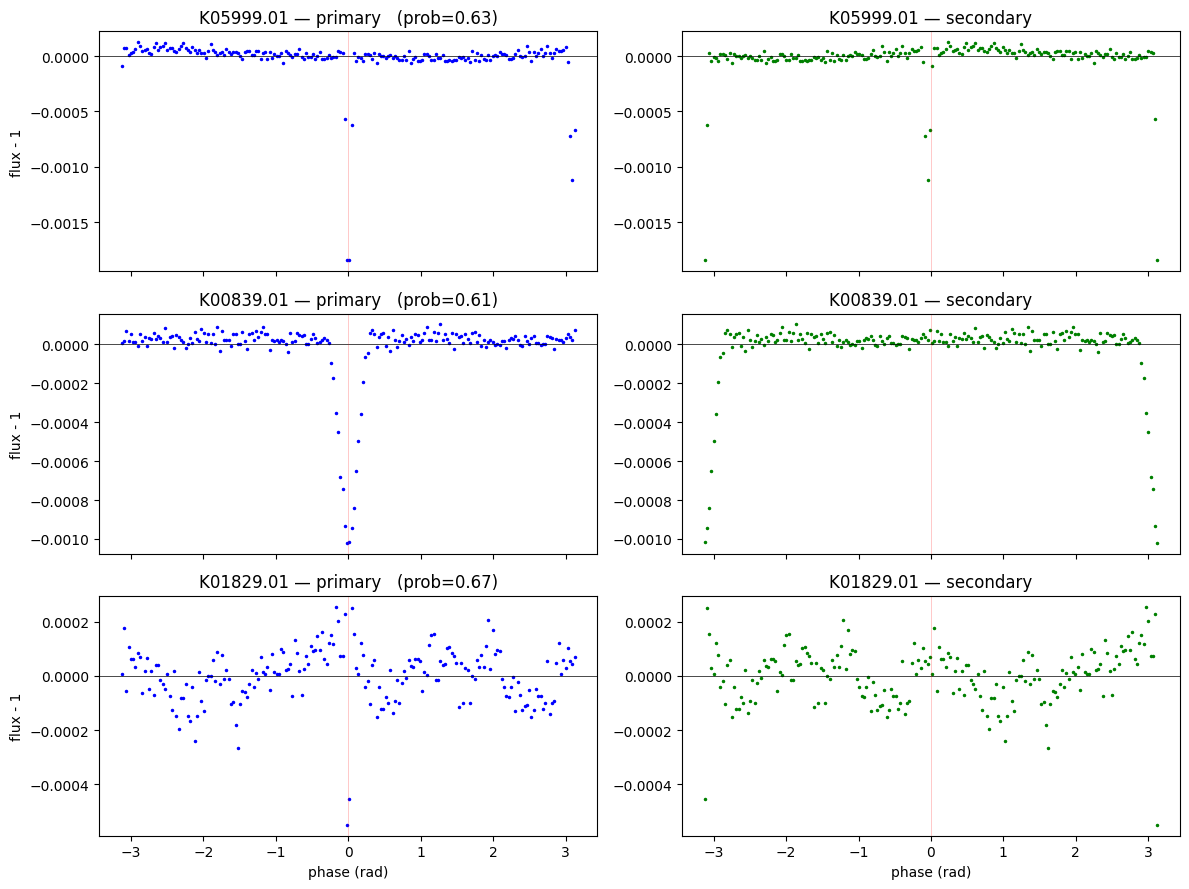

In [9]:
fp_positions = (((test_preds == 1) & (test_labels_cpu == 0)).nonzero(as_tuple=True)[0]).tolist()
test_idx_list = test_idx.tolist()

if not fp_positions:
    print('No false positives remain on the test set — V5 success.')
else:
    print(f'{len(fp_positions)} FPs remain. Inspecting...')
    fig, axes = plt.subplots(len(fp_positions), 2, figsize=(12, 3 * len(fp_positions)), squeeze=False, sharex=True)
    for row, pos in enumerate(fp_positions):
        orig = test_idx_list[pos]
        axes[row, 0].plot(phases[orig], fluxes_primary[orig],   'b.', ms=3)
        axes[row, 1].plot(phases[orig], fluxes_secondary[orig], 'g.', ms=3)
        for col in (0, 1):
            axes[row, col].axhline(0, color='k', lw=0.5)
            axes[row, col].axvline(0, color='r', lw=0.5, alpha=0.3)
        axes[row, 0].set_title(f'{names[orig]} — primary   (prob={test_probs[pos]:.2f})')
        axes[row, 1].set_title(f'{names[orig]} — secondary')
        axes[row, 0].set_ylabel('flux - 1')
    for ax in axes[-1]:
        ax.set_xlabel('phase (rad)')
    plt.tight_layout(); plt.show()

## 9. Save V5 model

In [10]:
save_path = '../src/models/taylor_cnn_v5.pt'
torch.save({
    'state_dict': model.state_dict(),
    'A': model.taylor_gate.A.item(),
    'metrics': {
        'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1,
    },
}, save_path)
print(f'Saved V5 model to {save_path}')
print(f'Taylor gate A = {model.taylor_gate.A.item():.5f}')

Saved V5 model to ../src/models/taylor_cnn_v5.pt
Taylor gate A = 0.01516
